# Version 1 - Wine Quality Regression

## Goals:
1. Load and inspect the red wine quality dataset.
2. Preprocess numeric features (Median Imputation + Standard Scaling).
3. Train a Random Forest Regressor using 5-fold Cross-Validation.
4. Evaluate model performance using RMSE (Root Mean Squared Error) and R² score.
5. Generate submission file for the test set.

## Imports & Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json

# Add src to path nếu cần custom modules
sys.path.append(os.path.abspath("src"))

# Sklearn cho Regression
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone






# Config
RANDOM_STATE = 42
N_SPLITS = 5
DATA_DIR = "data"
EXP_DIR = "experiments/WineReg_V1"

os.makedirs(EXP_DIR, exist_ok=True)
os.makedirs(os.path.join(EXP_DIR, "models"), exist_ok=True)

np.random.seed(RANDOM_STATE)

## 1. Load Data

In [2]:

DATA_DIR = "data"
TRAIN_FILE = "winequality-red.csv"

train_path = os.path.join(DATA_DIR, TRAIN_FILE)

columns = ["fixed_acidity","volatile_acidity","citric_acid","residual_sugar",
           "chlorides","free_sulfur_dioxide","total_sulfur_dioxide","density",
           "pH","sulphates","alcohol","quality"]

train_df = pd.read_csv(train_path, names=columns, header=None)

print(f"Train shape: {train_df.shape}")
display(train_df.head())

target_col = "quality"

print("\nTarget Summary:")
print(train_df[target_col].describe())


print("\nDistribution (normalized):")
print(train_df[target_col].value_counts(normalize=True).sort_index())

Train shape: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Target Summary:
count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

Distribution (normalized):
quality
3    0.006254
4    0.033146
5    0.425891
6    0.398999
7    0.124453
8    0.011257
Name: proportion, dtype: float64


## 2. Feature Definition & Preprocessing

We use the same numeric features as the baseline red wine dataset.

In [3]:

NUM_FEATURES = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
NUM_FEATURES.remove('quality')  # loại target ra khỏi features

X = train_df[NUM_FEATURES].copy()
y = train_df['quality'].copy()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUM_FEATURES),
    ]
)

rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

reg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_model),
    ]
)

## 3. Cross-Validation Training (5 Folds)

We train a **Random Forest Regressor** using **5-fold cross-validation**.  
Each fold splits the dataset into training and validation sets, ensuring the model is evaluated on different subsets of data.  

Model performance is measured using **RMSE** and **R² score** for each fold.  
Finally, we average the scores across folds to get the overall performance.

In [4]:


kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
oof_preds = np.zeros(len(y))
fold_metrics = []
models = []

print(f"Starting {N_SPLITS}-Fold CV...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    print(f"\n========== Fold {fold} ==========")
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = clone(reg_pipeline)  # pipeline đã định nghĩa với RandomForestRegressor
    model.fit(X_tr, y_tr)
    
    val_preds = model.predict(X_val)
    oof_preds[val_idx] = val_preds
    
    mse = mean_squared_error(y_val, val_preds)
    r2 = r2_score(y_val, val_preds)
    print(f"Fold {fold} MSE: {mse:.4f} | R2: {r2:.4f}")
    
    fold_metrics.append((mse, r2))
    models.append(model)
    
    # Save model
    model_path = os.path.join(EXP_DIR, "models", f"fold{fold}_rf.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)

# OOF Score
mse_list, r2_list = zip(*fold_metrics)
print("\n========== OOF Results ==========")
print(f"Mean MSE: {np.mean(mse_list):.4f} ± {np.std(mse_list):.4f}")
print(f"Mean R2: {np.mean(r2_list):.4f} ± {np.std(r2_list):.4f}")

Starting 5-Fold CV...

========== Fold 1 ==========
Fold 1 MSE: 0.3122 | R2: 0.5223

========== Fold 2 ==========
Fold 2 MSE: 0.3515 | R2: 0.4528

========== Fold 3 ==========
Fold 3 MSE: 0.3499 | R2: 0.4737

========== Fold 4 ==========
Fold 4 MSE: 0.3423 | R2: 0.5014

========== Fold 5 ==========
Fold 5 MSE: 0.2932 | R2: 0.5167

========== OOF Results ==========
Mean MSE: 0.3298 ± 0.0231
Mean R2: 0.4934 ± 0.0264


## 4. Evaluation & Diagnostics

We use a custom `Evaluation` class to analyze the model's performance on the out-of-fold predictions and validation sets.

Key steps include:

1. **Visualizing Predictions vs. True Values** – Check how well predicted wine quality matches the actual scores.
2. **Residual Analysis** – Plot residuals (prediction error) to detect any patterns or biases.
3. **Metric Summary** – Display RMSE and R² scores for each fold and overall performance.
4. **Feature Importance** – Optional: Show which numeric features contributed most to the Random Forest predictions.

OOF MSE: 0.3298, MAE: 0.4140, R2: 0.4939


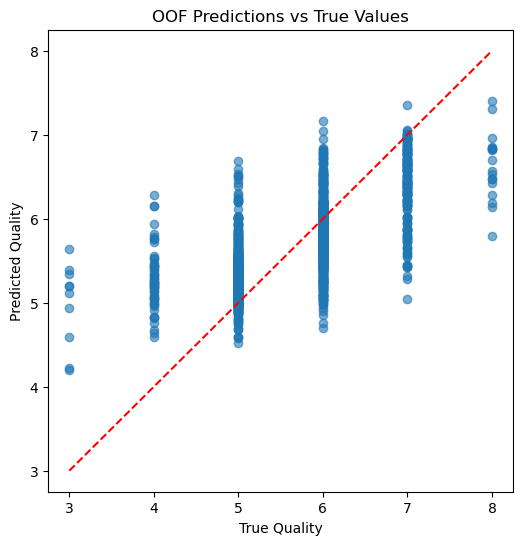

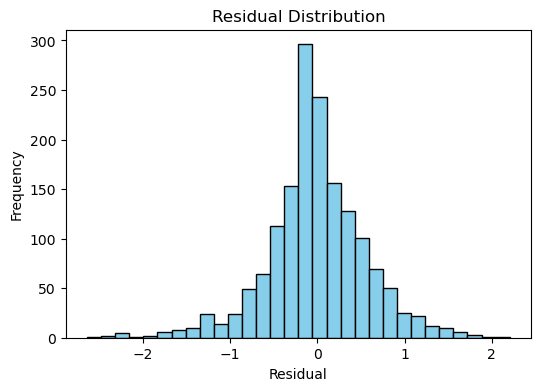

In [ ]:
y_true = y
y_pred = oof_preds  # trong regression sẽ là giá trị dự đoán

# Metrics
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"OOF MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

# Scatter plot y_true vs y_pred
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.xlabel("True Quality")
plt.ylabel("Predicted Quality")
plt.title("OOF Predictions vs True Values")
plt.show()

# Residual plot
residuals = y_true - y_pred
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='k')
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

## 5. Final Prediction & Submission

For the final submission, we generate predictions on the test set by **averaging the outputs** from the 5 fold models.  

Steps:

1. Load the 5 trained fold models.
2. Predict test set values with each model.
3. Take the **mean prediction** for each sample as the final output.
4. Save the predictions in the required submission format (CSV).

OOF RMSE: 0.5743
OOF R²: 0.4939


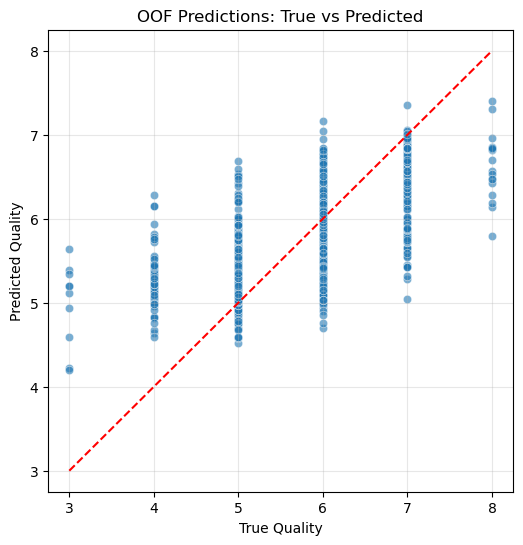

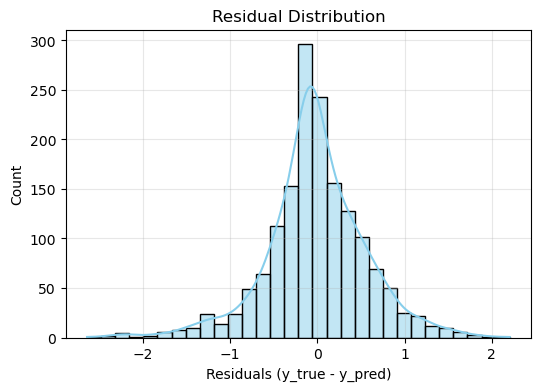

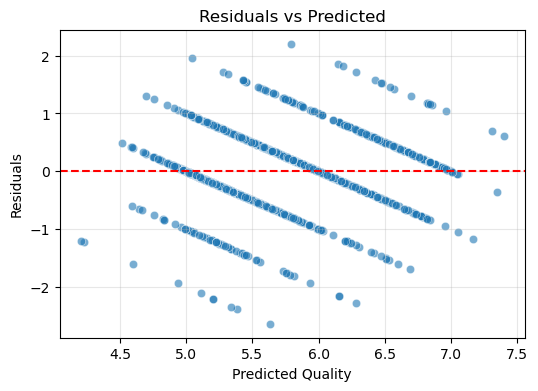

In [6]:

mse = mean_squared_error(y, oof_preds)


rmse = np.sqrt(mse)


r2 = r2_score(y, oof_preds)

print(f"OOF RMSE: {rmse:.4f}")
print(f"OOF R²: {r2:.4f}")


plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=oof_preds, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")  # y=x line
plt.xlabel("True Quality")
plt.ylabel("Predicted Quality")
plt.title("OOF Predictions: True vs Predicted")
plt.grid(alpha=0.3)
plt.show()


residuals = y - oof_preds
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True, color='skyblue')
plt.xlabel("Residuals (y_true - y_pred)")
plt.title("Residual Distribution")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=oof_preds, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Quality")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.grid(alpha=0.3)
plt.show()

## 6. Save Artifacts

In [7]:


MODEL_DIR = os.path.join("experiments", "WineReg_V1", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

for i, model in enumerate(models):
    model_path = os.path.join(MODEL_DIR, f"fold{i}_rf.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)

print(f"✅ Saved {len(models)} fold models to {MODEL_DIR}")

✅ Saved 5 fold models to experiments\WineReg_V1\models


In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# OOF predictions và target
mse = mean_squared_error(y, oof_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y, oof_preds)

report_df = pd.DataFrame({
    "Metric": ["RMSE", "R²"],
    "Value": [rmse, r2]
})

display(report_df)

,Metric,Value
0,RMSE,0.574315
1,R²,0.493928


In [9]:
REPORT_DIR = os.path.join("experiments", "WineReg_V1", "reports")
os.makedirs(REPORT_DIR, exist_ok=True)

report_df.to_csv(os.path.join(REPORT_DIR, "oof_metrics.csv"), index=False)
print(f"✅ OOF metrics saved to {REPORT_DIR}")

✅ OOF metrics saved to experiments\WineReg_V1\reports
